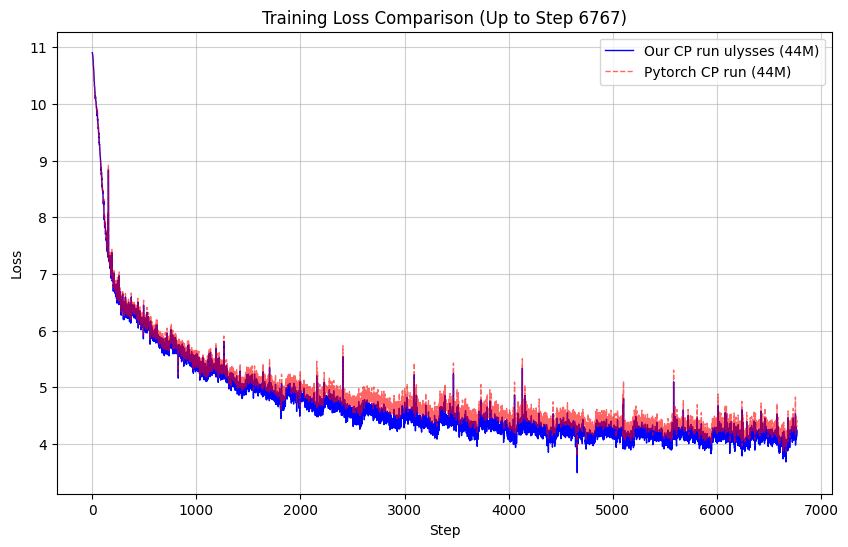

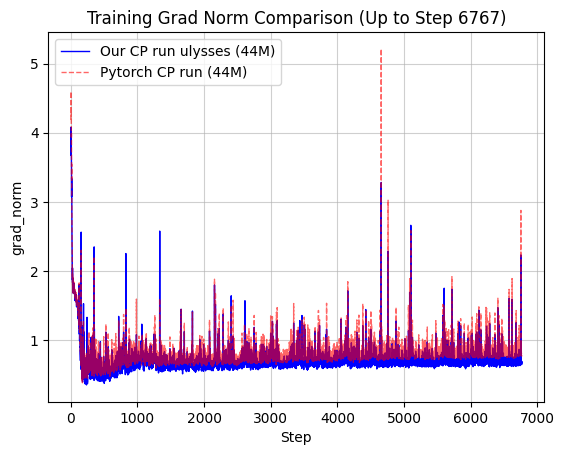

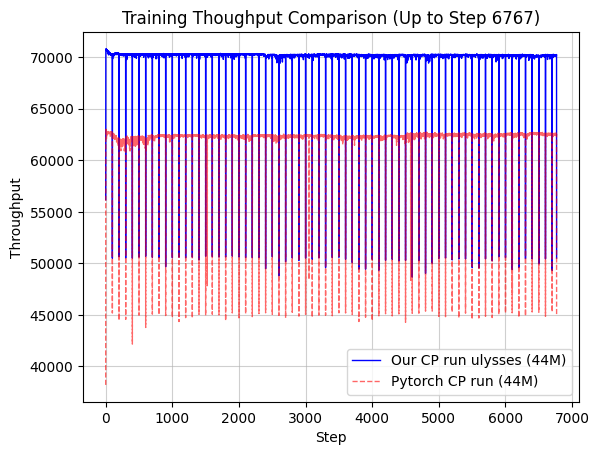

Max. Throughput Our CP run ulysses (44M): 70790.986365
Avg. Throughput Our CP run ulysses (44M): 70000.39638029522
Min Train Loss Our CP run ulysses (44M): 3.491954
Min Val Loss Our CP run ulysses (44M): 4.048149
Avg. Time Our CP run ulysses (44M): 937.2856371040191
Avg. Data Time Our CP run ulysses (44M): 0.5424184728132387
Avg. Forward Time Our CP run ulysses (44M): 293.9017062536938
Avg. Loss Time Our CP run ulysses (44M): 20.119960274083923
Avg. Backward Time Our CP run ulysses (44M): 566.6667512616725
Avg. Attention Time Our CP run ulysses (44M): 129.02959056619386
Avg. clip_grad Time Our CP run ulysses (44M): 1.0814744302600472
Avg. Optimizer Time Our CP run ulysses (44M): 3.7839437730496455
Avg. Tok_Emb Time Our CP run ulysses (44M): 0.31684330023640667
Avg. Pos_Emb Time Our CP run ulysses (44M): 0.16478524349881798
Avg. Mlp Time Our CP run ulysses (44M): 36.93867675650119
Avg. Ln_f Time Our CP run ulysses (44M): 0.47187653427895976
Avg. LM Head Time Our CP run ulysses (44M): 10

In [58]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log6.csv')
df_old = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/Pytorch/Pytorch_CP_AttnStyle_FP32_Training_logs/Pytorch_CP_AttnStyle_FP32_Training_log45.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Pytorch CP run (44M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Pytorch CP run (44M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Pytorch CP run (44M)',linewidth=1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput Our CP run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput Our CP run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss Our CP run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss Our CP run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time Our CP run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time Our CP run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time Our CP run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time Our CP run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time Our CP run ulysses (44M):",df_new['timer_bwd'][:].mean())
print("Avg. Attention Time Our CP run ulysses (44M):",df_new['timer_attn_cp'][:].mean())
print("Avg. clip_grad Time Our CP run ulysses (44M):",df_new['timer_clip'][:].mean())
print("Avg. Optimizer Time Our CP run ulysses (44M):",df_new['timer_optim'][:].mean())
print("Avg. Tok_Emb Time Our CP run ulysses (44M):",df_new['timer_tok_emb'][:].mean())
print("Avg. Pos_Emb Time Our CP run ulysses (44M):",df_new['timer_pos_emb'].mean())
print("Avg. Mlp Time Our CP run ulysses (44M):",df_new['timer_mlp'][:].mean())
print("Avg. Ln_f Time Our CP run ulysses (44M):",df_new['timer_ln_f'][:].mean())
print("Avg. LM Head Time Our CP run ulysses (44M):",df_new['timer_lm_head'][:].mean())


print("\nMax. Throughput Pytorch CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Pytorch CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Pytorch CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Pytorch CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Pytorch CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Pytorch CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Pytorch CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Pytorch CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Pytorch CP run (44M):",df_old_truncated['timer_bwd'][:].mean())
print("Avg. Attention Time Pytorch CP run (44M):",df_old_truncated['timer_attn_cp'][:].mean())
print("Avg. clip_grad Time Pytorch CP run (44M):",df_old_truncated['timer_clip'][:].mean())
print("Avg. Optimizer Time Pytorch CP run (44M):",df_old_truncated['timer_optim'][:].mean())
print("Avg. Tok_Emb Time Pytorch CP run (44M):",df_old_truncated['timer_tok_emb'][:].mean())
print("Avg. Pos_Emb Time Pytorch CP run (44M):",df_old_truncated['timer_pos_emb'].mean())
print("Avg. Mlp Time Pytorch CP run (44M):",df_old_truncated['timer_mlp'][:].mean())
print("Avg. Ln_f Time Pytorch CP run (44M):",df_old_truncated['timer_ln_f'][:].mean())
print("Avg. LM Head Time Pytorch CP run (44M):",df_old_truncated['timer_lm_head'][:].mean())



# print("\nMax. Throughput Our CP run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our CP run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our CP run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss Our CP run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our CP run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time Our CP run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our CP run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our CP run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our CP run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Our CP run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Our CP run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Our CP run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Our CP run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Our CP run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Our CP run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Our CP run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Our CP run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

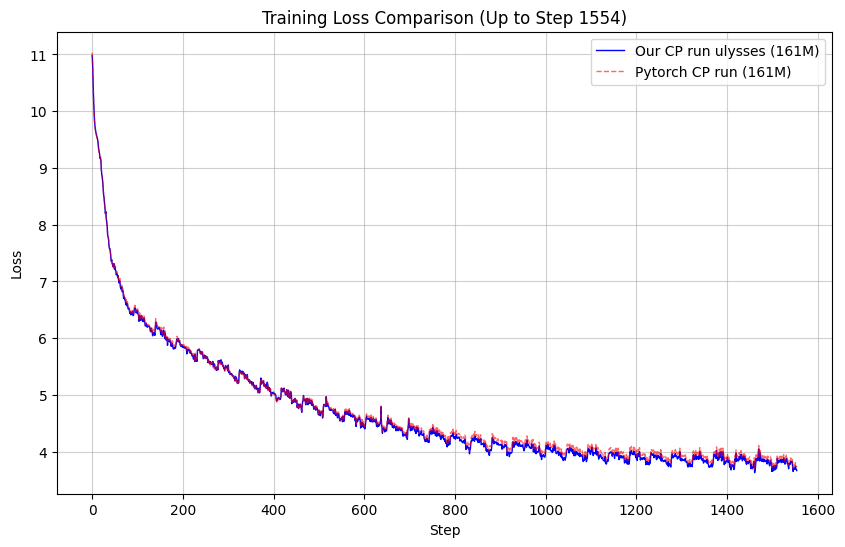

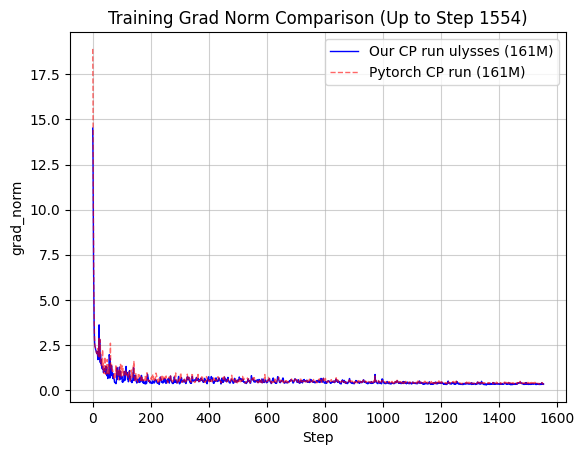

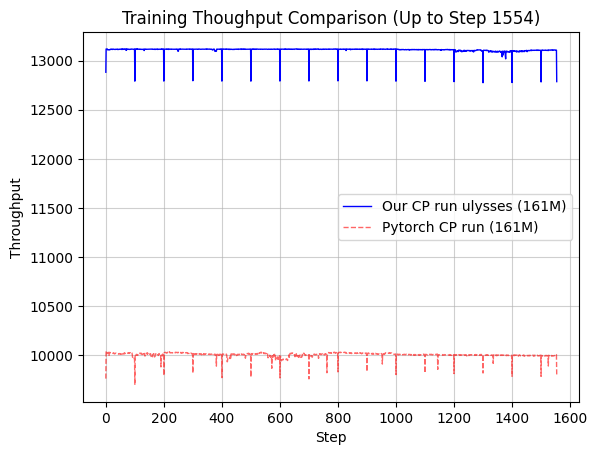

Max. Throughput Our CP run ulysses (161M): 13118.898111
Avg. Throughput Our CP run ulysses (161M): 13107.90996328103
Min Train Loss Our CP run ulysses (161M): 3.629564
Min Val Loss Our CP run ulysses (161M): 3.744764
Avg. Time Our CP run ulysses (161M): 39998.11118117042
Avg. Data Time Our CP run ulysses (161M): 6.020291004501608
Avg. Forward Time Our CP run ulysses (161M): 14956.814575551767
Avg. Loss Time Our CP run ulysses (161M): 161.10568124630225
Avg. Backward Time Our CP run ulysses (161M): 24659.716407217362
Avg. Attention Time Our CP run ulysses (161M): 8021.6413513903535
Avg. clip_grad Time Our CP run ulysses (161M): 4.499588177491962
Avg. Optimizer Time Our CP run ulysses (161M): 13.939056463665594
Avg. Tok_Emb Time Our CP run ulysses (161M): 4.731685659163986
Avg. Pos_Emb Time Our CP run ulysses (161M): 1.991468100321543
Avg. Mlp Time Our CP run ulysses (161M): 3428.423362278457
Avg. Ln_f Time Our CP run ulysses (161M): 5.75449048488746
Avg. LM Head Time Our CP run ulysses 

In [311]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_Training_logs/CP_Training_log7.csv')
df_old = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/Pytorch/Pytorch_CP_AttnStyle_FP32_Training_logs/Pytorch_CP_AttnStyle_FP32_Training_log41.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='Our CP run ulysses (161M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Pytorch CP run (161M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='Our CP run ulysses (161M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Pytorch CP run (161M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='Our CP run ulysses (161M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Pytorch CP run (161M)',linewidth=1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP run before (161M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput Our CP run ulysses (161M):",df_new['tok_per_sec'].max())
print("Avg. Throughput Our CP run ulysses (161M):",df_new['tok_per_sec'].mean())
print("Min Train Loss Our CP run ulysses (161M):",df_new['loss'][:].min())
print("Min Val Loss Our CP run ulysses (161M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time Our CP run ulysses (161M):",df_new['dt_ms'].mean())
print("Avg. Data Time Our CP run ulysses (161M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time Our CP run ulysses (161M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time Our CP run ulysses (161M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time Our CP run ulysses (161M):",df_new['timer_bwd'][:].mean())
print("Avg. Attention Time Our CP run ulysses (161M):",df_new['timer_attn_cp'][:].mean())
print("Avg. clip_grad Time Our CP run ulysses (161M):",df_new['timer_clip'][:].mean())
print("Avg. Optimizer Time Our CP run ulysses (161M):",df_new['timer_optim'][:].mean())
print("Avg. Tok_Emb Time Our CP run ulysses (161M):",df_new['timer_tok_emb'][:].mean())
print("Avg. Pos_Emb Time Our CP run ulysses (161M):",df_new['timer_pos_emb'].mean())
print("Avg. Mlp Time Our CP run ulysses (161M):",df_new['timer_mlp'][:].mean())
print("Avg. Ln_f Time Our CP run ulysses (161M):",df_new['timer_ln_f'][:].mean())
print("Avg. LM Head Time Our CP run ulysses (161M):",df_new['timer_lm_head'][:].mean())


print("\nMax. Throughput Pytorch CP run (161M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Pytorch CP run (161M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Pytorch CP run (161M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Pytorch CP run (161M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Pytorch CP run (161M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Pytorch CP run (161M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Pytorch CP run (161M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Pytorch CP run (161M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Pytorch CP run (161M):",df_old_truncated['timer_bwd'][:].mean())
print("Avg. Attention Time Pytorch CP run (161M):",df_old_truncated['timer_attn_cp'][:].mean())
print("Avg. clip_grad Time Pytorch CP run (161M):",df_old_truncated['timer_clip'][:].mean())
print("Avg. Optimizer Time Pytorch CP run (161M):",df_old_truncated['timer_optim'][:].mean())
print("Avg. Tok_Emb Time Pytorch CP run (161M):",df_old_truncated['timer_tok_emb'][:].mean())
print("Avg. Pos_Emb Time Pytorch CP run (161M):",df_old_truncated['timer_pos_emb'].mean())
print("Avg. Mlp Time Pytorch CP run (161M):",df_old_truncated['timer_mlp'][:].mean())
print("Avg. Ln_f Time Pytorch CP run (161M):",df_old_truncated['timer_ln_f'][:].mean())
print("Avg. LM Head Time Pytorch CP run (161M):",df_old_truncated['timer_lm_head'][:].mean())



# print("\nMax. Throughput Our CP run before (161M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our CP run before (161M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our CP run before (161M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss Our CP run before (161M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our CP run before (161M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time Our CP run before (161M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our CP run before (161M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our CP run before (161M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our CP run before (161M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Our CP run before (161M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Our CP run before (161M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Our CP run before (161M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Our CP run before (161M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Our CP run before (161M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Our CP run before (161M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Our CP run before (161M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Our CP run before (161M):",df_3rd_truncated['timer_lm_head'][:].mean())